In [8]:
##tools
import arxiv
from langchain.tools import tool


In [10]:
def search_arxiv(query: str, max_results: int = 2):
    client = arxiv.Client(
        page_size=5,
        delay_seconds=3,
        num_retries=3
    )
    search = arxiv.Search(
        query=query,
        max_results=max_results,
        sort_by=arxiv.SortCriterion.Relevance
    )
    results = client.results(search)
    return results

In [11]:
@tool
def arxiv_search(query: str, max_results: int = 2):
    """Search arXiv for papers matching the query."""
    results = search_arxiv(query, max_results)
    return "\n".join([f"{result.title} ({result.pdf_url})" for result in results])

In [12]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

In [13]:
api_wrapper_wiki = WikipediaAPIWrapper(top_k_results=2, doc_content_chars_max=200)
wiki = WikipediaQueryRun(api_wrapper=api_wrapper_wiki, description="Useful for when you need to answer questions about general knowledge.")
wiki

WikipediaQueryRun(description='Useful for when you need to answer questions about general knowledge.', api_wrapper=WikipediaAPIWrapper(wiki_client=<module 'wikipedia' from 'c:\\Users\\racha\\AppData\\Local\\Programs\\Python\\Python311\\Lib\\site-packages\\wikipedia\\__init__.py'>, top_k_results=2, lang='en', load_all_available_meta=False, doc_content_chars_max=200))

In [14]:
from dotenv import load_dotenv
load_dotenv()

import os

os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")
os.environ["GROK_API_KEY"] = os.getenv("GROK_API_KEY")

In [15]:
from langchain_tavily import TavilySearch

tavily = TavilySearch(max_results=5)


In [16]:
tavily.invoke("gimme the recent ai news")

{'query': 'gimme the recent ai news',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.reddit.com/r/AISEOInsider/comments/1rs1o1v/latest_ai_news_the_biggest_ai_announcements_right/',
   'title': 'Latest AI News: The Biggest AI Announcements Right Now - Reddit',
   'content': 'Latest AI news includes new AI tools, company announcements, research breakthroughs, and startup funding. Which AI Tools Appeared In Latest AI',
   'score': 0.67037153,
   'raw_content': None},
  {'url': 'https://www.artificialintelligence-news.com/',
   'title': 'AI News | Latest News | Insights Powering AI-Driven Business Growth',
   'content': 'AI News delivers the latest updates in artificial intelligence, machine learning, deep learning, enterprise AI, and emerging tech worldwide.',
   'score': 0.5608546,
   'raw_content': None},
  {'url': 'https://www.reuters.com/technology/artificial-intelligence/',
   'title': 'AI News | Latest Headlines and Developments | Reu

In [17]:
##combine all these tools
tools = [wiki, tavily, arxiv_search]

In [18]:
from langchain_groq import ChatGroq

llm = ChatGroq(model="llama-3.1-8b-instant", api_key=os.getenv("GROK_API_KEY"))

In [19]:
llm.invoke("What are the recent news about ai?")

AIMessage(content='Here are some recent news about AI (keep in mind that AI is a rapidly evolving field, and new developments are emerging every day):\n\n1. **Google\'s AI Research Breakthroughs**: Google has made significant advancements in AI research, including the development of a new AI model called "Gemini," which is designed to assist with natural language processing tasks.\n2. **AI-Powered Chatbots**: Companies like Meta, Microsoft, and IBM are developing AI-powered chatbots that can engage in conversations, answer questions, and provide customer support.\n3. **Self-Driving Cars**: Multiple companies, including Waymo, Tesla, and Cruise, are testing self-driving cars and making progress towards commercializing autonomous vehicles.\n4. **AI-Assisted Healthcare**: AI is being used to analyze medical images, diagnose diseases, and develop personalized treatment plans. For example, Google\'s AI-powered Lyra platform helps doctors diagnose breast cancer more accurately.\n5. **AI in E

In [20]:
llm_with_tools = llm.bind_tools(tools=tools)

In [22]:
llm_with_tools.invoke("what is the latest news on Waaree?")

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'n0bgnqqk5', 'function': {'arguments': '{"query":"Waaree latest news","time_range":"day","topic":"news"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 33, 'prompt_tokens': 1834, 'total_tokens': 1867, 'completion_time': 0.055578108, 'completion_tokens_details': None, 'prompt_time': 0.347571864, 'prompt_tokens_details': None, 'queue_time': 0.108370202, 'total_time': 0.403149972}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e4676-d68d-7f70-a572-337beee3af0e-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'Waaree latest news', 'time_range': 'day', 'topic': 'news'}, 'id': 'n0bgnqqk5', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 1834, 'output_tokens': 33, 'total_tokens': 186

In [28]:
##workflow using langgraph
from typing_extensions import TypedDict
from typing import Annotated   ## for type annotations
from langchain_core.messages import AnyMessage, HumanMessage## human message or ai message
from langgraph.graph.message import add_messages ##reducers in langgraph

In [24]:
class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages] ## this is the reducer, it will add messages to the state
    # list of all the ai, sys and human messages in the conversation history
    #add_messages doesnt override it appends to it, so we can keep track of the conversation history

In [ ]:
from IPython.display import display, Image
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition


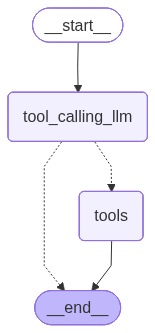

In [26]:
##node definitions
def tool_calling_llm(state: State):
    ##call the llm with tools and get the response
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

##build the graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools=tools))

##edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)
builder.add_edge("tools", END)

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))


In [29]:
messages = graph.invoke({"messages": HumanMessage(content="1706.03762")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

1706.03762
================================== Ai Message ==================================
Tool Calls:
  arxiv_search (ttwg1fr7w)
 Call ID: ttwg1fr7w
  Args:
    max_results: 2
    query: 1706.03762
================================= Tool Message =================================
Name: arxiv_search

Attention Is All You Need (https://arxiv.org/pdf/1706.03762v7)
GLU Variants Improve Transformer (https://arxiv.org/pdf/2002.05202v1)


In [30]:
messages = graph.invoke({"messages" : "go through the recent quantum computing news and gimme the summary of them"})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

go through the recent quantum computing news and gimme the summary of them
================================== Ai Message ==================================
Tool Calls:
  tavily_search (g69byb6mp)
 Call ID: g69byb6mp
  Args:
    query: quantum computing recent news
    search_depth: advanced
    time_range: month
    topic: news
  tavily_search (673da16hw)
 Call ID: 673da16hw
  Args:
    query: quantum computing breakthroughs
    search_depth: advanced
    time_range: month
    topic: news
  tavily_search (twe2jdkmg)
 Call ID: twe2jdkmg
  Args:
    query: quantum computing advancements
    search_depth: advanced
    time_range: month
    topic: news
  tavily_search (rgj8792j3)
 Call ID: rgj8792j3
  Args:
    query: quantum computing updates
    search_depth: advanced
    time_range: month
    topic: news
  tavily_search (01z33nmnx)
 Call ID: 01z33nmnx
  Args:
    query: quantum computing research
    searc

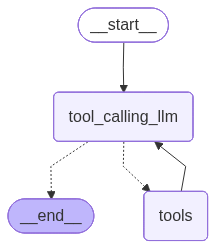

In [39]:
##node definitions
def tool_calling_llm(state: State):
    ##call the llm with tools and get the response
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

##build the graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools=tools))

##edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)
builder.add_edge("tools", "tool_calling_llm") ## we want to go back to the llm after calling the tools, so it can decide if it needs to call more tools or give the final answer

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))


In [40]:
messages = graph.invoke({"messages" : "go through the recent quantum computing news and gimme the summary of them"})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

go through the recent quantum computing news and gimme the summary of them
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (p2hrx5st3)
 Call ID: p2hrx5st3
  Args:
    query: recent quantum computing news
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Quantum Computers News -- ScienceDaily", "url": "https://www.sciencedaily.com/news/computers_math/quantum_computers/", "content": "ScienceDaily\n\n# Quantum Computers News\n\n## Top Headlines\n\n## Latest Headlines\n\n## Earlier Headlines\n\n### Tuesday, January 20, 2026\n\n### Tuesday, January 6, 2026\n\n### Friday, December 26, 2025\n\n### Tuesday, January 6, 2026\n\n### Tuesday, December 23, 2025\n\n### Tuesday, January 27, 2026\n\n### Saturday, November 29, 2025\n\n### Sunday, November 16, 2025\n\n### Th

In [41]:
messages = graph.invoke({"messages" : "tell me about recent google i/o keynote and gimme top quantum computing research papers."})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

tell me about recent google i/o keynote and gimme top quantum computing research papers.
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (a996ma2qk)
 Call ID: a996ma2qk
  Args:
    query: latest Google I/O keynote
  arxiv_search (e9mn5bwyc)
 Call ID: e9mn5bwyc
  Args:
    max_results: 5
    query: quantum computing
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Google I/O 2026 Live Recap: Everything Announced - CNET", "url": "https://www.cnet.com/news-live/google-io-2026-live-news-updates/", "content": "# Google I/O 2026 Live: Gemini Omni, Smart Glasses and More AI\n\nGoogle's annual developer conference kicked off with a keynote Tuesday. We'll be bringing you updates throughout the conference.\n\nHeadshot of Mike Sorrentino\nHeadshot of Mike Sorrentino\